In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#PANDAS
#Load the dataset
df= pd.read_csv('/kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv')
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [11]:
#display the first 10 rows.
df.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [12]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [13]:
#Find the shape of the dataset.
df.shape

(2200, 8)

In [96]:
#Display basic information about columns and data types.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [14]:
#Statistical Summary of Numeric Columns
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [15]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [17]:
#
#check missing values in the dataset
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [103]:
#Find the number of unique crop labels.
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [ ]:
#Remove duplicate rows from the dataset.
df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Handle Missing Values
df.isnull().sum()
df.dropna() #remve
#or
#df.fillna(df.mean(0))
df.fillna(df.mean(numeric_only=True), inplace=True)

In [106]:
maximum=df['label'].value_counts().idxmax()
print("Mostly grow:",maximum )
minimum= df['label'].value_counts().idxmin()

print("Less grow:", minimum)

Mostly grow: rice
Less grow: rice


In [107]:
# more then one higest
counts = df['label'].value_counts()

max_count = counts.max()

top_crops = counts[counts == max_count]

print(top_crops)

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


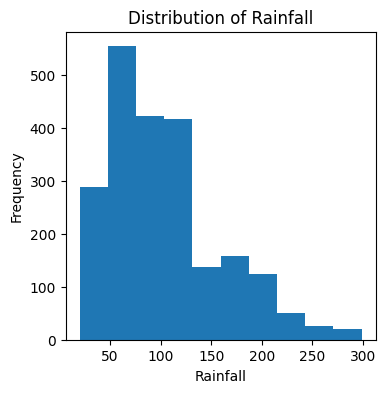

In [40]:
#Plot the distribution of rainfall using a histogram.
#histogram: one numeric column
plt.figure(figsize=(4,4))
plt.hist(df['rainfall'], bins= 10)
plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall') #rainfall amounts
plt.ylabel('Frequency') #data points fall in each range
plt.show()

#This pattern is called right‑skewed distribution, 
#meaning the dataset has many small rainfall values and only a few large ones.
#dataset experienced moderate rainfall, and heavy rainfall was rare.

In [ ]:
#average=df['rainfall'].mean()
#print(average)

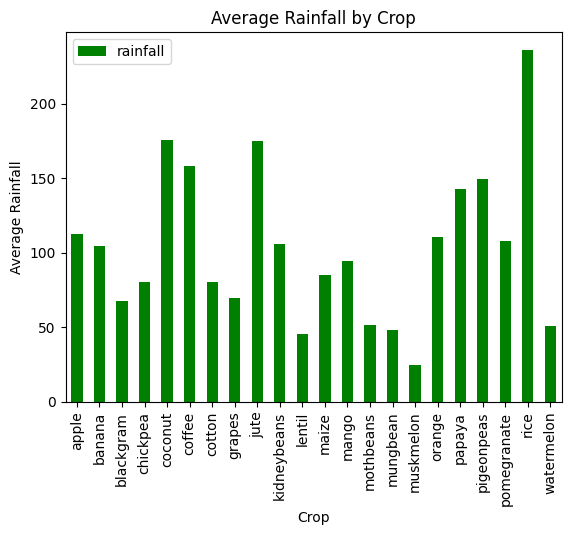

In [41]:
df.groupby('label')['rainfall'].mean().plot(kind='bar', color= 'green')

plt.xlabel("Crop") #diffrent crops 
plt.ylabel("Average Rainfall") # average rainfall (in millimeters)
plt.title("Average Rainfall by Crop")
plt.legend()
plt.show()
#Rice has the highest average rainfall, meaning it grows best in wetter conditions.
#Crops like muskmelon and lentil have shorter bars, showing they need much less rainfall.
#Most other crops fall somewhere in between, with moderate rainfall requirements.

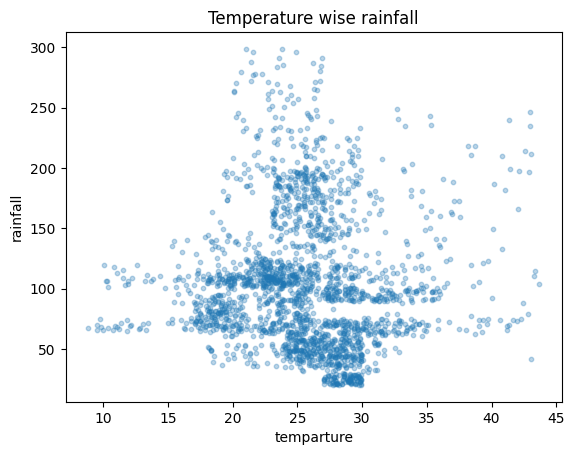

In [50]:
#scatter plot between temp and rainfall
plt.scatter(df['temperature'], df['rainfall'], s=10, alpha=0.3)
plt.title('Temperature wise rainfall')
plt.xlabel('temparture')
plt.ylabel('rainfall')

plt.show()
#You can see clusters around 20–30 °C and 50–200 mm rainfall, 
#meaning most crops grow in moderate temperature and rainfall conditions.

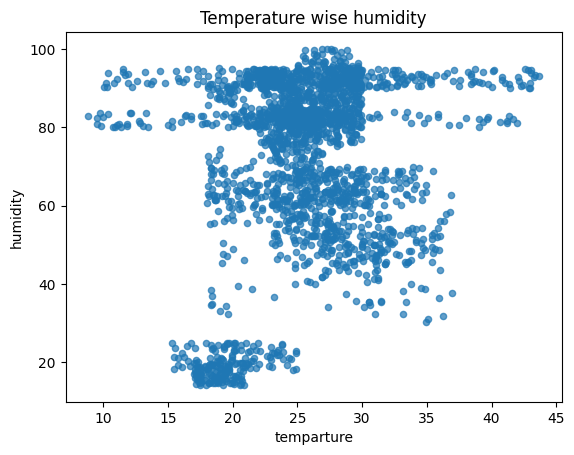

In [58]:
#scatter plot
plt.scatter(df['temperature'], df['humidity'], s=20, alpha=0.7)
plt.title('Temperature wise humidity')
plt.xlabel('temparture')
plt.ylabel('humidity')
plt.show()
#Most dots are grouped between 20 °C and 30 °C temperature and 60–90 % humidity —
#that’s the comfortable zone for most crops.

In [72]:
crop_count= df['label'].value_counts()

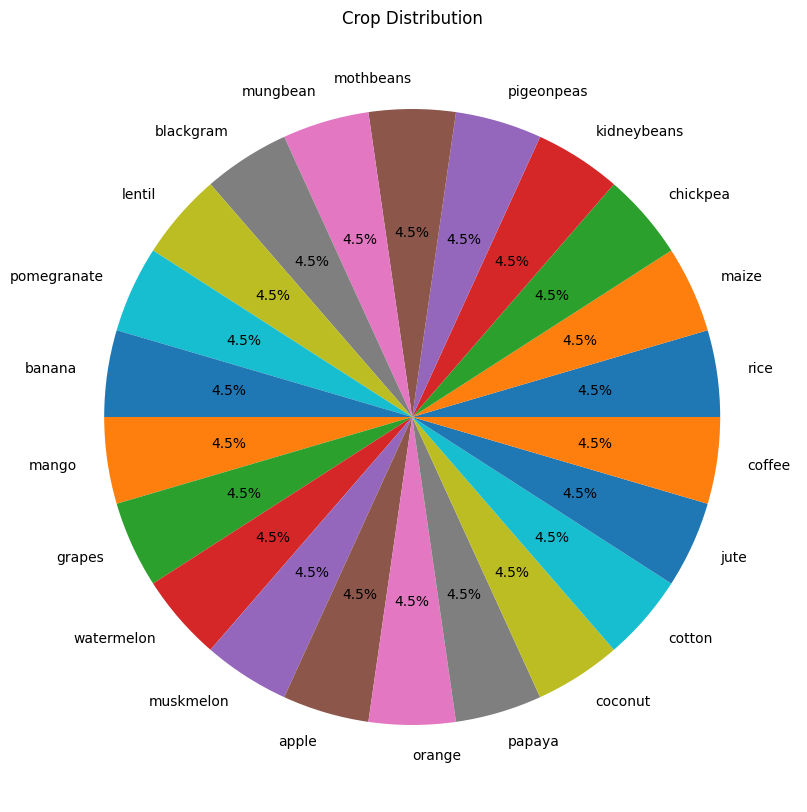

In [79]:
#pie chart
plt.figure(figsize=(10,10))
plt.pie(crop_count,labels=crop_count.index, autopct='%1.1f%%')
plt.title('Crop Distribution')
plt.show()
#Every crop takes up equal space (4.5%),
#meaningdataset has the same number of samples for each crop.

In [ ]:
#boxplot

In [84]:
#start decision tree
#prepare data
#axis=0 means rows and axis=1 mean column
X= df.drop('label', axis=1) #take input except label col
y=df['label']

In [92]:
#import libraries
#train_test_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [86]:
#Split dataset into training and testing sets (80/20).
X_train,X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [88]:
#decision tree
model=  DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [89]:
#Predict crop labels for test data.
y_pred = model.predict(X_test)

In [91]:
#Calculate accuracy of the model.
print("Accuracy:", accuracy_score(y_test, y_pred))
#accray: 98 percent

Accuracy: 0.9886363636363636


In [93]:
#confusion matrix
print(confusion_matrix(y_test, y_pred))
#

[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  1  0  0 22  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

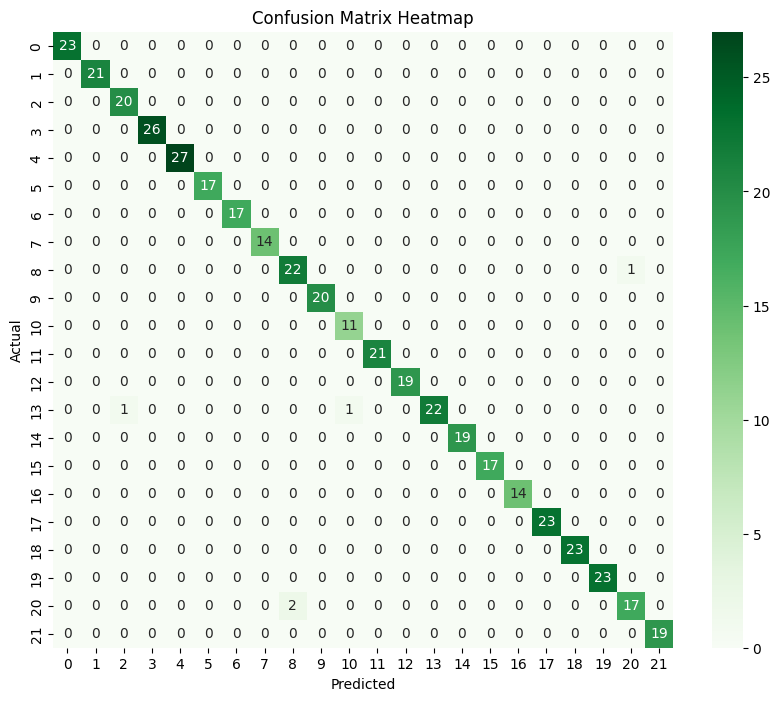

In [95]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
#“The model predicted almost every crop correctly, with only 1–2 misclassifications, which is why accuracy is about 99%.”
#example: crop “Rice” had 20 test samples, the diagonal entry for Rice will be 20 if all were predicted correctly.

In [94]:
print(classification_report(y_test, y_pred))
#lets take one
#for jute
#Precision: 0.92 when the model predicts jute, it’s right 92% of the time.
#Recall: 0.96 → it correctly identifies 96% of the actual jute samples.
#F1‑score: 0.94 → balanced measure of precision and recall.
#Support: 23 → there were 23 jute samples in the test set.

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      0.96      0.94        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    